In [34]:
import numpy as np 
from sklearn import datasets
import sklearn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split

In [7]:
digits = datasets.load_digits()         #download the data 
print(digits.images.shape)
print(digits.keys())


(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


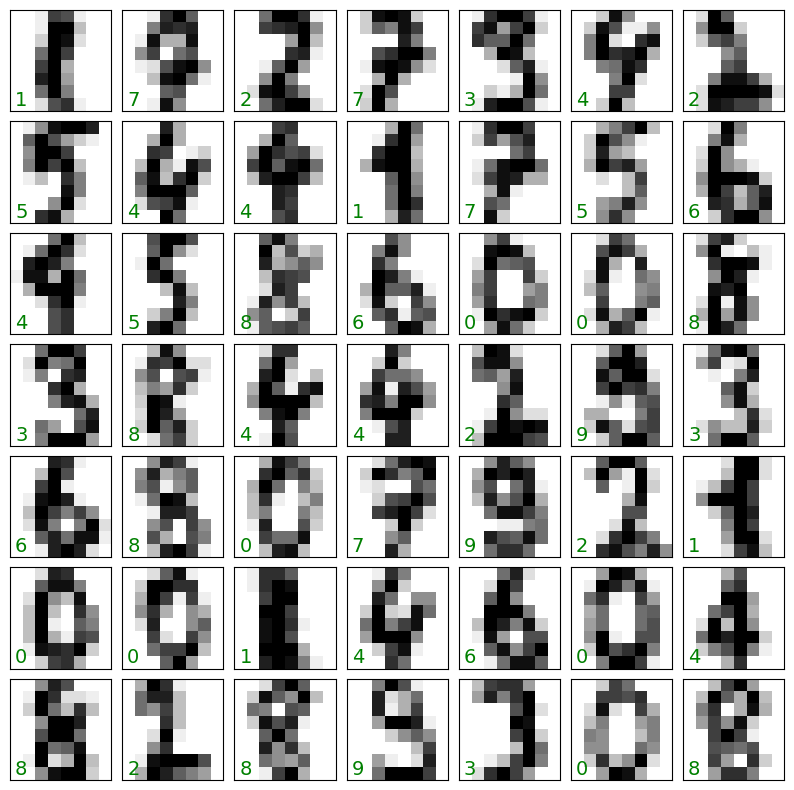

In [10]:
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(42)
mychoices = np.random.choice(digits.images.shape[0],100)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

In [ ]:
print(digits.data.shape)

# The images themselves
print(digits.images[1]) #of the 2nd image 

# The data for use in our algorithms
print(digits.data[1])

# The labels
print(digits.target)
print(digits.target[1])


(1797, 64)
[[ 0.  0. 11. 12.  0.  0.  0.  0.]
 [ 0.  2. 16. 16. 16. 13.  0.  0.]
 [ 0.  3. 16. 12. 10. 14.  0.  0.]
 [ 0.  1. 16.  1. 12. 15.  0.  0.]
 [ 0.  0. 13. 16.  9. 15.  2.  0.]
 [ 0.  0.  0.  3.  0.  9. 11.  0.]
 [ 0.  0.  0.  0.  9. 15.  4.  0.]
 [ 0.  0.  9. 12. 13.  3.  0.  0.]]
[ 0.  0.  0. 12. 13.  5.  0.  0.  0.  0.  0. 11. 16.  9.  0.  0.  0.  0.
  3. 15. 16.  6.  0.  0.  0.  7. 15. 16. 16.  2.  0.  0.  0.  0.  1. 16.
 16.  3.  0.  0.  0.  0.  1. 16. 16.  6.  0.  0.  0.  0.  1. 16. 16.  6.
  0.  0.  0.  0.  0. 11. 16. 10.  0.  0.]
[0 1 2 ... 8 9 8]
1


In [50]:
N=2 #number of dimensions 
embedding = sklearn.manifold.Isomap(n_components=N, n_neighbors=10)
data_red = embedding.fit_transform(digits.data)
data_red.shape



(1797, 2)

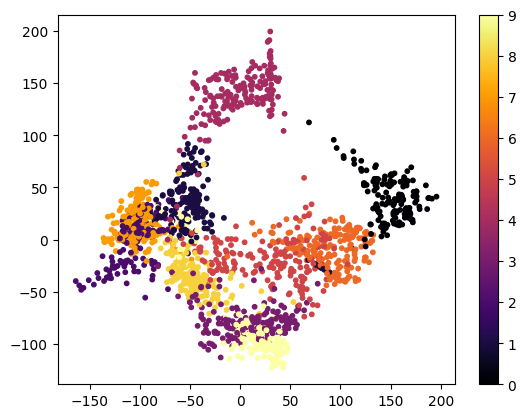

In [42]:
plt.scatter(data_red[:, 0], data_red[:, 1], cmap="inferno" ,c=digits.target, s=10)
plt.colorbar()

In [48]:
X_train, X_test = train_test_split(data_red, test_size=0.2, random_state=16) #test size is 20% of the data
